--- Opening Global OISST v2.1 Dataset ---

     OISST TIMELINE NAN DETAILED INSPECTION REPORT        
✨ Perfect Dataset! No missing time-series NaNs detected in OISST (1982-2010).

--- Cleaned OISST Monthly Anomaly Sample (1982-2010 Base) ---
         Date  Year  Month       ATL3  ATL3_SSTA
0  1982-01-01  1982      1  27.418152   0.169935
1  1982-02-01  1982      2  28.054163   0.204826
2  1982-03-01  1982      3  28.625425   0.193899
3  1982-04-01  1982      4  28.335115  -0.202841
4  1982-05-01  1982      5  27.447294  -0.301853
5  1982-06-01  1982      6  25.162468  -0.889702
6  1982-07-01  1982      7  23.770470  -0.926817
7  1982-08-01  1982      8  23.426048  -0.968111
8  1982-09-01  1982      9  24.357561  -0.552847
9  1982-10-01  1982     10  25.074465  -0.612564
10 1982-11-01  1982     11  25.483831  -0.750483
11 1982-12-01  1982     12  26.010616  -0.651873
-------------------------------------------------------------



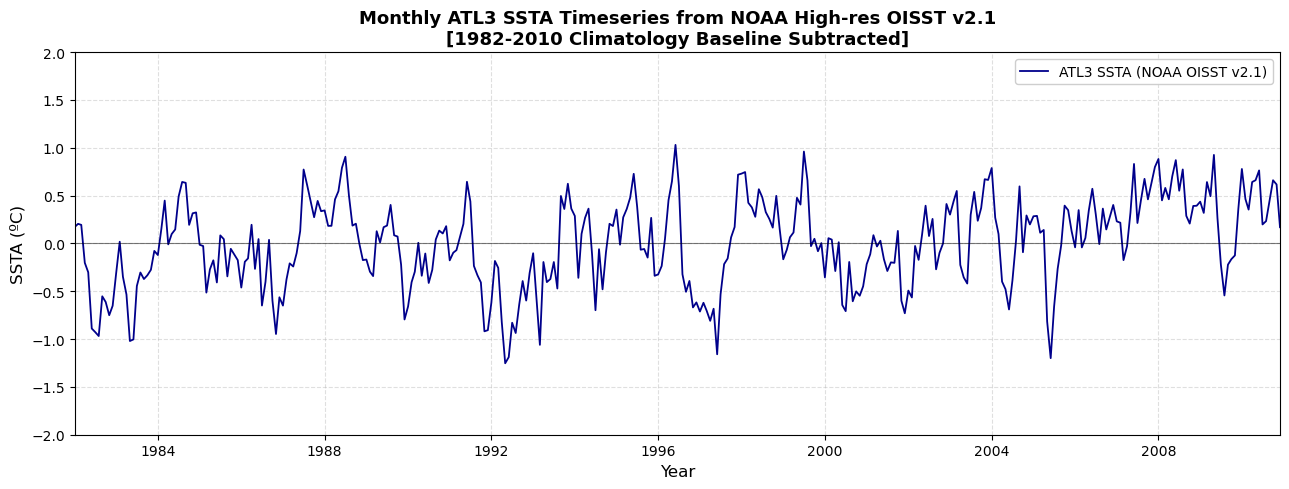

In [17]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 1. Define OISST file path
base_dir = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/OBS"
file_path = os.path.join(base_dir, "OISST_sst.mon.mean.nc")

print("--- Opening Global OISST v2.1 Dataset ---")
# Standard netcdf4 engine reads single file OISST smoothly
ds_global = xr.open_dataset(file_path, engine='netcdf4')

# -------------------------------------------------------------------------
# [CRITICAL BOX FILTERING] 
# OISST coordinates alignment: 
# - Latitude is naturally sequential [-89.875 to 89.875], so we slice [-3, 3]
# - Longitude spans [0 to 360]. Western longitudes must be converted:
#   20°W -> 360 - 20 = 340°E | 0° -> 360°E (or 0°E)
# -------------------------------------------------------------------------
lat_name = 'lat'
lon_name = 'lon'
time_name = 'time'

# Slice ATL3 region precisely using OISST's native coordinates
ds_atl3 = ds_global.sel(**{
    lat_name: slice(-3.0, 3.0),
    lon_name: slice(340.0, 360.0)
})

# 2. Compute spatial mean to collapse into a single dimensional timeseries
with np.errstate(all='ignore'):
    atl3_spatial_mean = ds_atl3['sst'].mean(dim=[lat_name, lon_name], skipna=True)

# 3. Construct clean Pandas DataFrame and normalize time axis
time_cleaned = pd.to_datetime(ds_global[time_name].values)
# Enforce Day=1 to match initialized prediction model timesteps
time_standardized = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_cleaned])

df = pd.DataFrame({
    'Date': time_standardized,
    'ATL3': atl3_spatial_mean.values
})
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Filter timeline to align with your model evaluation boundary (1982-2010)
df = df[(df['Year'] >= 1982) & (df['Year'] <= 2010)].reset_index(drop=True)

# -------------------------------------------------------------------------
# [ANOMALY PROCESSING] Deduct 1982-2010 Monthly Climatology Baseline
# [MODIFIED] Adjusted window from '1991-01-01' to '1982-01-01' to expand reference base
# -------------------------------------------------------------------------
obs_clim_mask = (df['Date'] >= "1982-01-01") & (df['Date'] <= "2010-12-01")

obs_monthly_clim = {
    m: df.loc[obs_clim_mask & (df['Month'] == m), 'ATL3'].mean() 
    for m in range(1, 13)
}

df['ATL3_SSTA'] = df.apply(lambda row: row['ATL3'] - obs_monthly_clim[row['Month']], axis=1)

# -------------------------------------------------------------------------
# [DIAGNOSIS] Missing Values (NaN) Check Report
# -------------------------------------------------------------------------
print("\n==========================================================")
print("     OISST TIMELINE NAN DETAILED INSPECTION REPORT        ")
print("==========================================================")
nan_indices = df[df['ATL3_SSTA'].isna() | np.isnan(df['ATL3_SSTA'])]

if len(nan_indices) > 0:
    print(f"🚨 Total missing months found in OISST timeline: {len(nan_indices)} months")
    print(nan_indices[['Date', 'Year', 'Month', 'ATL3_SSTA']])
else:
    print("✨ Perfect Dataset! No missing time-series NaNs detected in OISST (1982-2010).")
print("==========================================================\n")

print("--- Cleaned OISST Monthly Anomaly Sample (1982-2010 Base) ---")
print(df[['Date', 'Year', 'Month', 'ATL3', 'ATL3_SSTA']].head(12))
print("-------------------------------------------------------------\n")

# 4. Plot the Pure Monthly OISST ATL3 SSTA Timeseries
plt.figure(figsize=(13, 5))
plt.plot(df['Date'], df['ATL3_SSTA'], color='darkblue', linewidth=1.3, label='ATL3 SSTA (NOAA OISST v2.1)')

plt.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
plt.title("Monthly ATL3 SSTA Timeseries from NOAA High-res OISST v2.1\n[1982-2010 Climatology Baseline Subtracted]", fontsize=13, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("SSTA (ºC)", fontsize=12)
plt.xlim(df['Date'].min(), df['Date'].max())
plt.ylim(-2.0, 2.0)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right', framealpha=0.95)

plt.tight_layout()
ds_global.close()
plt.show()

In [3]:
import os
import numpy as np
import xarray as xr
import pandas as pd

# =========================================================================
# 1. Configuration
# =========================================================================
models = [
    "CanCM4i", "CanSIPS-IC4", "CanSIPSv2", "CMC1-CanCM3", "CMC2-CanCM4",
    "GEM-NEMO", "GFDL-SPEAR", "NASA-GEOSS2S", "NCAR-CESM1", "NCEP-CFSv2"
]
run_types = ["HINDCAST", "FORECAST"]

base_dir = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME"

all_results = []
merged_results = []

# =========================================================================
# 2. Loop through Models to Compute Spatial Average
# =========================================================================
for model in models:
    model_data = {}  # Store HINDCAST and FORECAST dataframes for the current model
    
    for run_type in run_types:
        target_dir = f"{base_dir}/{model}/SST/ATL3/{run_type}"
        
        if not os.path.exists(target_dir):
            continue
            
        file_pattern = f"{target_dir}/{model}_SST_ATL3_{run_type}_*.nc"
        
        try:
            # open_mfdataset automatically chains the yearly files
            ds = xr.open_mfdataset(file_pattern, combine='by_coords', use_cftime=True)
            
            # Calculate Latitude Weights: cos(lat)
            weights = np.cos(np.deg2rad(ds.Y))
            weights.name = "weights"
            
            # Compute Area-Weighted Mean
            sst_weighted = ds['sst'].weighted(weights)
            atl3_index = sst_weighted.mean(dim=['X', 'Y'])
            
            # Convert to DataFrame and add tracking columns
            df_slice = atl3_index.to_dataframe(name='atl3_sst').reset_index()
            df_slice['model'] = model
            df_slice['run_type'] = run_type
            
            # Save to global list for HINDCAST/FORECAST separate output
            all_results.append(df_slice)
            
            # Save to model-specific dict for the merging process
            model_data[run_type] = df_slice
            
        except Exception as e:
            print(f"--> [ERROR] Failed to process {model} {run_type}: {e}")

    # -----------------------------------------------------------------
    # [NEW] Merge HINDCAST and FORECAST (Priority: HINDCAST > FORECAST)
    # -----------------------------------------------------------------
    if "HINDCAST" in model_data or "FORECAST" in model_data:
        print(f"Creating Merged (Seamless) Dataset for: {model}")
        
        hc = model_data.get("HINDCAST", pd.DataFrame())
        fc = model_data.get("FORECAST", pd.DataFrame())
        
        if hc.empty:
            # If only FORECAST exists
            merged_df = fc.copy()
        elif fc.empty:
            # If only HINDCAST exists
            merged_df = hc.copy()
        else:
            # Both exist: Set indices to align coordinates (S, M, L)
            idx_cols = ['S', 'M', 'L']
            hc_indexed = hc.set_index(idx_cols)
            fc_indexed = fc.set_index(idx_cols)
            
            # Base data is FORECAST, then update/overwrite with HINDCAST wherever available
            # combine_first uses hc values first, and fills missing rows/NaNs with fc values
            merged_indexed = hc_indexed.combine_first(fc_indexed)
            
            merged_df = merged_indexed.reset_index()
            merged_df['model'] = model
            
        # Label this run_type as 'MERGED'
        merged_df['run_type'] = 'MERGED'
        merged_results.append(merged_df)

# =========================================================================
# 3. Merge and Save Final Combined Outputs
# =========================================================================
if all_results:
    print("\nSaving Consolidated Files...")
    
    # Combine HINDCAST, FORECAST, and MERGED dataframes into one mega-dataframe
    final_list = all_results + merged_results
    final_df = pd.concat(final_list, ignore_index=True)
    
    # Reorder columns
    final_df = final_df[['model', 'run_type', 'S', 'M', 'L', 'atl3_sst']]
    
    # Save as CSV
    csv_out = f"{base_dir}/NMME_ATL3_SST_weighted_all_models.csv"
    final_df.to_csv(csv_out, index=False)
    print(f"[SUCCESS] Saved to CSV (Includes MERGED): {csv_out}")
    
    # Save as NetCDF
    # Multidimensional xarray dataset structured by indices
    final_ds = final_df.set_index(['model', 'run_type', 'S', 'M', 'L']).to_xarray()
    nc_out = f"{base_dir}/NMME_ATL3_SST_weighted_all_models.nc"
    final_ds.to_netcdf(nc_out)
    print(f"[SUCCESS] Saved to NetCDF (Includes MERGED): {nc_out}")
    
    # Quick Summary Print
    print("\n--- Data Summary (Row Counts per Run Type) ---")
    print(final_df.groupby(['model', 'run_type']).size())

else:
    print("[ERROR] No data was processed.")

Creating Merged (Seamless) Dataset for: CanCM4i
Creating Merged (Seamless) Dataset for: CanSIPS-IC4
Creating Merged (Seamless) Dataset for: CanSIPSv2
Creating Merged (Seamless) Dataset for: CMC1-CanCM3
Creating Merged (Seamless) Dataset for: CMC2-CanCM4
Creating Merged (Seamless) Dataset for: GEM-NEMO
Creating Merged (Seamless) Dataset for: GFDL-SPEAR
Creating Merged (Seamless) Dataset for: NASA-GEOSS2S
Creating Merged (Seamless) Dataset for: NCAR-CESM1
--> [ERROR] Failed to process NCEP-CFSv2 FORECAST: no files to open
Creating Merged (Seamless) Dataset for: NCEP-CFSv2

Saving Consolidated Files...
[SUCCESS] Saved to CSV (Includes MERGED): /Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.csv
[SUCCESS] Saved to NetCDF (Includes MERGED): /Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.nc

--- Data Summary (Row Counts per Run Type) ---
model      

Step 1: Loading OISST v2.1 with Cos-Latitude AREA-WEIGHTING (Strict 1982-2010)...
--- Area-Weighted & Detrended 1982-2010 OISST Observation Complete ---

Step 3: Calculating Lead-Dependent Persistence skill...
Step 4: Processing individual models with uniform Lead-1 trend removal (1982-2010 Base)...
Step 5: Computing Multi-Model Ensemble (MME) skill vs OISST...
Step 6: Generating high-fidelity skill plots...
👉 Successfully exported 'skill_comparison_plot.jpg'
Step 7: Rendering verification-synchronized diagnostic timelines...
👉 Successfully exported 'timeseries_diagnostics_plot.jpg'

All procedures successfully synchronized and written to disk.


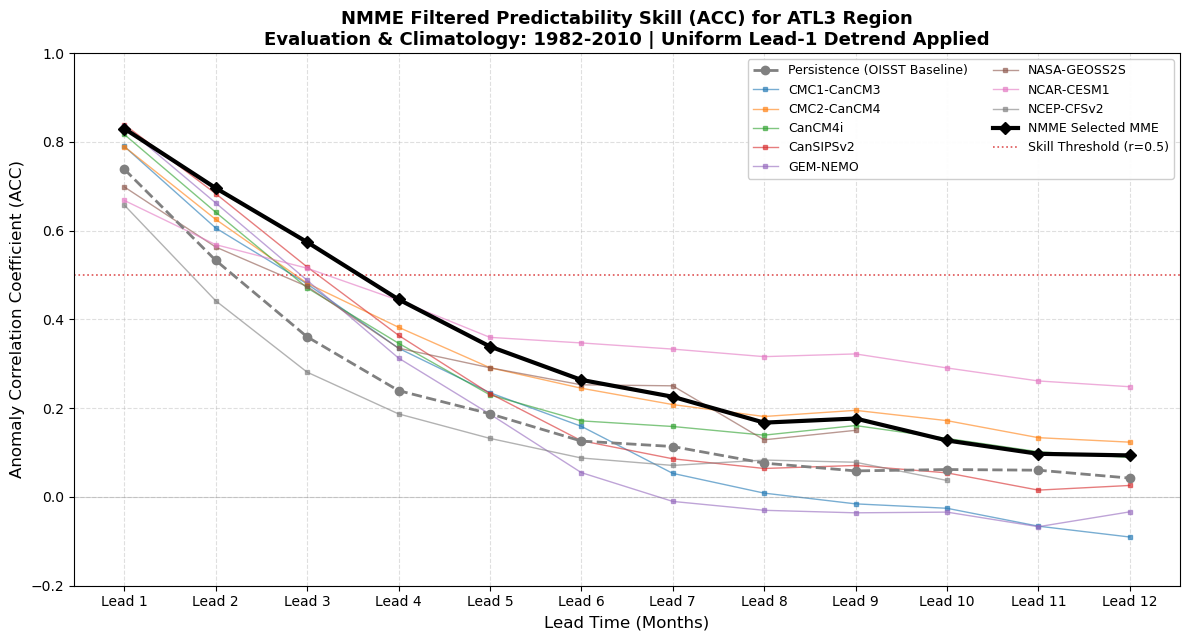

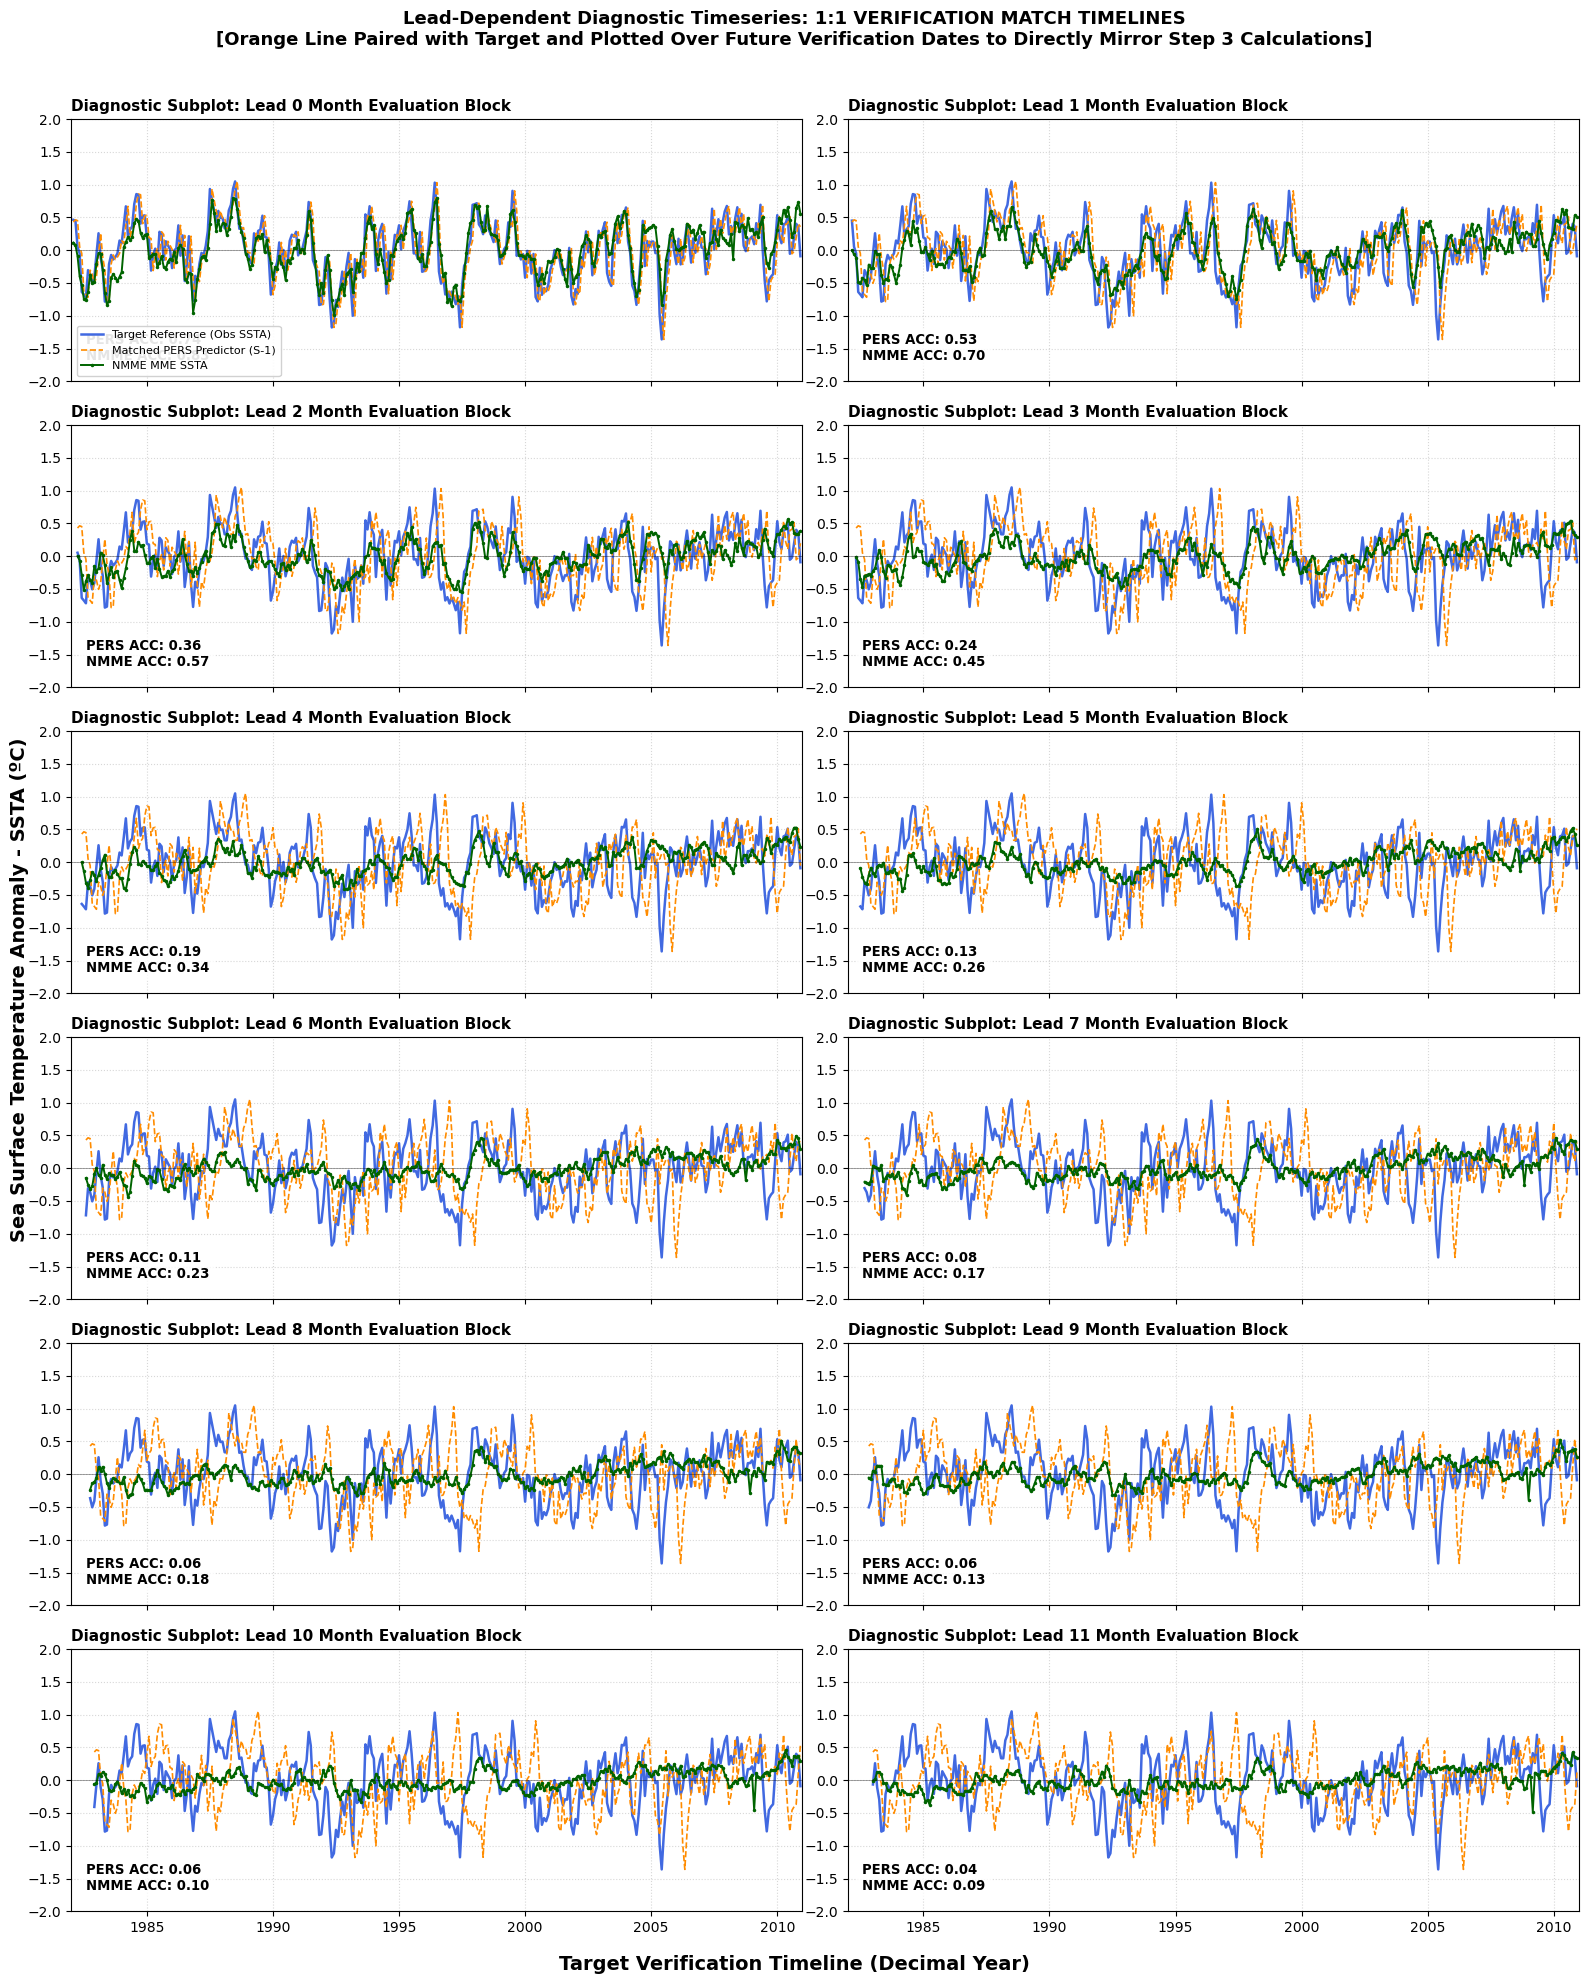

In [31]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import detrend
from scipy.stats import pearsonr, linregress
import os

# =========================================================================
# 1. Load and Process Observation Data (Area-Weighted, Climatology First -> Detrend Next)
# =========================================================================
print("Step 1: Loading OISST v2.1 with Cos-Latitude AREA-WEIGHTING (Strict 1982-2010)...")
oisst_dir = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/OBS"
oisst_path = os.path.join(oisst_dir, "OISST_sst.mon.mean.nc")

ds_global = xr.open_dataset(oisst_path, engine='netcdf4')
ds_atl3 = ds_global.sel(lat=slice(-3.0, 3.0), lon=slice(340.0, 360.0))

# Area weights
weights = np.cos(np.deg2rad(ds_atl3['lat']))
weights.name = "weights"

with np.errstate(all='ignore'):
    atl3_spatial_mean = ds_atl3['sst'].weighted(weights).mean(dim=['lat', 'lon'], skipna=True)

time_cleaned = pd.to_datetime(ds_global['time'].values)
time_standardized = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_cleaned])

df_obs_all = pd.DataFrame({
    'Date': time_standardized,
    'ATL3_raw_SST': atl3_spatial_mean.values
})
df_obs_all['Year'] = df_obs_all['Date'].dt.year
df_obs_all['Month'] = df_obs_all['Date'].dt.month

# Strict 1982-2010 Bounding
df_obs = df_obs_all[(df_obs_all['Year'] >= 1982) & (df_obs_all['Year'] <= 2010)].reset_index(drop=True)

# Compute Anomaly First based on 1982-2010 Climatology Baseline Period
obs_clim_mask = (df_obs['Date'] >= "1982-01-01") & (df_obs['Date'] <= "2010-12-01")
obs_monthly_clim = {
    m: df_obs.loc[obs_clim_mask & (df_obs['Month'] == m), 'ATL3_raw_SST'].mean() 
    for m in range(1, 13)
}
df_obs['ATL3_SSTA_raw'] = df_obs.apply(lambda row: row['ATL3_raw_SST'] - obs_monthly_clim[row['Month']], axis=1)

# Detrend Anomaly Next
df_obs['ATL3_SSTA'] = detrend(df_obs['ATL3_SSTA_raw'].values)
df_obs_indexed = df_obs.set_index('Date')

print("--- Area-Weighted & Detrended 1982-2010 OISST Observation Complete ---\n")


# =========================================================================
# 2. Define Target Settings & Bounding Filters
# =========================================================================
nc_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.nc"
ds_all = xr.open_dataset(nc_path)
ds_merged = ds_all.sel(run_type="MERGED")

target_models = [
    'CanCM4i', 'CanSIPSv2', 'CMC1-CanCM3', 'CMC2-CanCM4', 
    'GEM-NEMO', 'NASA-GEOSS2S', 'NCAR-CESM1', 'NCEP-CFSv2'
]

models = [m for m in ds_merged.model.values if m in target_models]
leads = ds_merged.L.values  

# Timing boundaries bounded tightly from 1982-2010 for full sync
start_eval = pd.Timestamp("1982-01-01")
end_eval = pd.Timestamp("2010-12-01")    
start_clim = pd.Timestamp("1982-01-01")
end_clim = pd.Timestamp("2010-12-01")    

model_skills = {model: [] for model in models}
persistence_skills = []
model_anom_dict = {}


# =========================================================================
# 3. Compute Persistence Forecast Skill (1982-2010)
# =========================================================================
print("Step 3: Calculating Lead-Dependent Persistence skill...")
with np.errstate(all='ignore'):
    for l_idx, lead in enumerate(leads):
        obs_predictor_list = []
        obs_target_list = []
        
        df_period = df_obs[(df_obs['Date'] >= start_eval) & (df_obs['Date'] <= end_eval)]
        
        for _, row in df_period.iterrows():
            init_date = row['Date']
            # [CRITICAL FIX]: Anchor is the month PRIOR to initialization (S - 1)
            persistence_anchor_date = init_date - pd.DateOffset(months=1)
            # [CRITICAL FIX]: Target is lead months in the FUTURE (S + Lead)
            target_date = init_date + pd.DateOffset(months=int(lead))
            
            if (persistence_anchor_date in df_obs_indexed.index) and (target_date in df_obs_indexed.index):
                obs_predictor_list.append(df_obs_indexed.loc[persistence_anchor_date, 'ATL3_SSTA'])
                obs_target_list.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
                
        if len(obs_predictor_list) > 10:
            r_val, _ = pearsonr(obs_predictor_list, obs_target_list)
            persistence_skills.append(r_val)
        else:
            persistence_skills.append(np.nan)


# =========================================================================
# 4. Compute Model Forecast Skills & Save Clean Anomalies (Uniform Lead-1 Trend Replicated)
# =========================================================================
print("Step 4: Processing individual models with uniform Lead-1 trend removal (1982-2010 Base)...")
for model_name in models:
    ds_mod = ds_merged.sel(model=model_name).sortby('S')
    time_axis_raw = ds_mod['S'].values
    time_axis_S = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_axis_raw])
    ds_mod = ds_mod.assign_coords(S=time_axis_S)
    
    # Isolate baseline data for climatology (1982-2010)
    baseline_ds = ds_mod.sel(S=slice(start_clim, end_clim))
    
    # Build 2D Climatology Matrix (month: 12, L: len(leads))
    with np.errstate(all='ignore'):
        master_clim_field = baseline_ds['atl3_sst'].mean(dim='M').groupby('S.month').mean(dim='S')
    
    clim_np_matrix = master_clim_field.values  
    gfdl_ssta_raw = ds_mod['atl3_sst'].copy(deep=True)
    
    # 4a. Subtract Climatology first to obtain raw anomalies
    for l_idx, lead in enumerate(leads):
        init_months_idx = ds_mod['S'].dt.month.values - 1
        mapped_clim_np = clim_np_matrix[init_months_idx, l_idx]
        
        for m_idx in range(len(ds_mod.M)):
            gfdl_ssta_raw.loc[dict(L=lead, M=ds_mod.M.values[m_idx])] = \
                ds_mod['atl3_sst'].sel(L=lead, M=ds_mod.M.values[m_idx]).values - mapped_clim_np
    
    # 4b. Calculate linear trend based strictly on Lead 1 and subtract from ALL leads
    gfdl_ssta = gfdl_ssta_raw.copy(deep=True)
    lead_1_val = leads[0] 
    x_steps = np.arange(len(ds_mod['S']))
    
    for m_idx in range(len(ds_mod.M)):
        lead_1_series = gfdl_ssta_raw.sel(L=lead_1_val, M=ds_mod.M.values[m_idx]).values
        
        if not np.isnan(lead_1_series).any():
            slope, intercept, r_value, p_value, std_err = linregress(x_steps, lead_1_series)
            trend_line = slope * x_steps
            
            for lead in leads:
                gfdl_ssta.loc[dict(L=lead, M=ds_mod.M.values[m_idx])] = \
                    gfdl_ssta_raw.sel(L=lead, M=ds_mod.M.values[m_idx]).values - trend_line
        else:
            for lead in leads:
                raw_series = gfdl_ssta_raw.sel(L=lead, M=ds_mod.M.values[m_idx]).values
                if not np.isnan(raw_series).any():
                    gfdl_ssta.loc[dict(L=lead, M=ds_mod.M.values[m_idx])] = detrend(raw_series)

    ens_mean_anom = gfdl_ssta.mean(dim='M')
    model_anom_dict[model_name] = ens_mean_anom.sel(S=slice(start_eval, end_eval))
    
    # Calculate Individual Model ACC against OISST
    eval_model_anom = model_anom_dict[model_name]
    eval_S_dates = eval_model_anom['S'].values
    
    with np.errstate(all='ignore'):
        for l_idx, lead in enumerate(leads):
            model_vals_list = []
            obs_vals_list = []
            for S_time in eval_S_dates:
                S_pd = pd.Timestamp(S_time)
                target_date = S_pd + pd.DateOffset(months=int(lead))
                if target_date in df_obs_indexed.index:
                    model_vals_list.append(eval_model_anom.sel(S=S_time, L=lead).values.item())
                    obs_vals_list.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
            
            if len(model_vals_list) > 10 and not np.isnan(model_vals_list).all():
                r_val, _ = pearsonr(model_vals_list, obs_vals_list)
                model_skills[model_name].append(r_val)
            else:
                model_skills[model_name].append(np.nan)


# =========================================================================
# 5. Compute Multi-Model Ensemble (MME) Mean Skill
# =========================================================================
print("Step 5: Computing Multi-Model Ensemble (MME) skill vs OISST...")
mme_skills = []
mme_forecast_dict = {} 

with np.errstate(all='ignore'):
    for l_idx, lead in enumerate(leads):
        mme_vals_list = []
        obs_vals_list = []
        mme_time_map = {}
        
        for S_time in eval_S_dates:
            S_pd = pd.Timestamp(S_time)
            target_date = S_pd + pd.DateOffset(months=int(lead))
            
            if target_date in df_obs_indexed.index:
                step_forecasts = []
                for model_name in models:
                    mod_anom = model_anom_dict[model_name]
                    if S_time in mod_anom['S'].values:
                        val = mod_anom.sel(S=S_time, L=lead).values.item()
                        if not np.isnan(val):
                            step_forecasts.append(val)
                
                if len(step_forecasts) > 0:
                    mean_f_val = np.mean(step_forecasts)
                    mme_vals_list.append(mean_f_val)
                    obs_vals_list.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
                    mme_time_map[target_date] = mean_f_val 
        
        mme_forecast_dict[lead] = mme_time_map
        if len(mme_vals_list) > 10:
            r_val, _ = pearsonr(mme_vals_list, obs_vals_list)
            mme_skills.append(r_val)
        else:
            mme_skills.append(np.nan)


# =========================================================================
# 6. Plotting the Ultimate Comparison Plot
# =========================================================================
print("Step 6: Generating high-fidelity skill plots...")
fig1, ax1 = plt.subplots(figsize=(12, 6.5))
lead_months = np.arange(1, len(leads) + 1)

ax1.plot(lead_months, persistence_skills, color='gray', linewidth=2.0, 
         linestyle='--', marker='o', label='Persistence (OISST Baseline)', zorder=8)

for model_name, skills in model_skills.items():
    if not np.isnan(skills).all():
        ax1.plot(lead_months, skills, linewidth=1.0, marker='s', markersize=3, alpha=0.6, label=model_name)

ax1.plot(lead_months, mme_skills, color='black', linewidth=3.0, 
         linestyle='-', marker='D', markersize=6, label='NMME Selected MME', zorder=15)

ax1.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.3)
ax1.axhline(0.5, color='tab:red', linestyle=':', linewidth=1.2, alpha=0.8, label='Skill Threshold (r=0.5)')

ax1.set_title("NMME Filtered Predictability Skill (ACC) for ATL3 Region\nEvaluation & Climatology: 1982-2010 | Uniform Lead-1 Detrend Applied", fontsize=13, fontweight='bold')
ax1.set_xlabel("Lead Time (Months)", fontsize=12)
ax1.set_ylabel("Anomaly Correlation Coefficient (ACC)", fontsize=12)
ax1.set_xticks(lead_months)
ax1.set_xticklabels([f"Lead {m}" for m in lead_months])
ax1.set_ylim(-0.2, 1.0)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.95)

plt.tight_layout()
# Save Plot 1 as high-resolution JPG
fig1.savefig("skill_comparison_plot.jpg", dpi=300, format='jpg')
print("👉 Successfully exported 'skill_comparison_plot.jpg'")


# =========================================================================
# 7. Multi-Panel Timeseries Diagnostics (PERFECT SYNC TO STEP 3 CORRELATION ENGINE)
# =========================================================================
print("Step 7: Rendering verification-synchronized diagnostic timelines...")
fig2, axes2 = plt.subplots(nrows=6, ncols=2, figsize=(16, 20), sharex=True)
axes_flat2 = axes2.flatten()

# We step exactly through the continuous initialization timeline as defined in Step 3 loop
initialization_timeline = pd.date_range(start="1982-01-01", end="2010-12-01", freq="MS")

for idx, lead in enumerate(leads):
    ax = axes_flat2[idx]
    
    target_series = []
    predictor_series = []
    nmme_series = []
    plot_years = []
    
    # Mirror the data pairing logic of Step 3 exactly
    for init_date in initialization_timeline:
        # [CRITICAL FIX MATCHING STEP 3]: Correct Offset Direction
        persistence_anchor_date = init_date - pd.DateOffset(months=1)
        target_date = init_date + pd.DateOffset(months=int(lead))
        
        # Pull if and only if both pairing elements are present in the dataset matrix
        if (persistence_anchor_date in df_obs_indexed.index) and (target_date in df_obs_indexed.index):
            # Plotted strictly at the Target Verification Year coordinate to judge correlation success
            plot_years.append(target_date.year + (target_date.month - 1)/12.0)
            
            # Line 1: The actual target anomaly observation
            target_series.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
            
            # Line 2: The historical anchor observation (The predictor)
            predictor_series.append(df_obs_indexed.loc[persistence_anchor_date, 'ATL3_SSTA'])
            
            # Line 3: The corresponding NMME forecast anomaly
            if target_date in mme_forecast_dict[lead]:
                nmme_series.append(mme_forecast_dict[lead][target_date])
            else:
                nmme_series.append(np.nan)

    # Re-verify local panel ACCs over these exact extracted vectors
    v_p = ~np.isnan(predictor_series) & ~np.isnan(target_series)
    v_m = ~np.isnan(nmme_series) & ~np.isnan(target_series)
    
    acc_p = pearsonr(np.array(predictor_series)[v_p], np.array(target_series)[v_p])[0] if sum(v_p) > 5 else np.nan
    acc_m = pearsonr(np.array(nmme_series)[v_m], np.array(target_series)[v_m])[0] if sum(v_m) > 5 else np.nan

    # Plot lines 1:1 on top of each other at Target Verification Time
    ax.plot(plot_years, target_series, color='royalblue', linewidth=1.8, label='Target Reference (Obs SSTA)')
    ax.plot(plot_years, predictor_series, color='darkorange', linewidth=1.2, linestyle='--', label=f'Matched PERS Predictor (S-1)')
    ax.plot(plot_years, nmme_series, color='darkgreen', linewidth=1.4, linestyle='-', marker='o', markersize=1.5, label='NMME MME SSTA')
    
    ax.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.set_xlim(1982, 2011)
    ax.set_ylim(-2.0, 2.0)
    ax.grid(True, linestyle=':', alpha=0.5)
    
    metric_box = f"PERS ACC: {acc_p:.2f}\nNMME ACC: {acc_m:.2f}"
    ax.text(0.02, 0.08, metric_box, transform=ax.transAxes, fontsize=9.5, 
            fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    ax.set_title(f"Diagnostic Subplot: Lead {int(lead)} Month Evaluation Block", fontsize=11, fontweight='bold', loc='left')
    if idx == 0:
        ax.legend(loc='lower left', fontsize=8, framealpha=0.9)

for i in range(len(leads), len(axes_flat2)):
    fig2.delaxes(axes_flat2[i])

fig2.text(0.5, 0.01, 'Target Verification Timeline (Decimal Year)', ha='center', fontsize=14, fontweight='bold')
fig2.text(0.01, 0.5, 'Sea Surface Temperature Anomaly - SSTA (ºC)', va='center', rotation='vertical', fontsize=14, fontweight='bold')
plt.suptitle("Lead-Dependent Diagnostic Timeseries: 1:1 VERIFICATION MATCH TIMELINES\n[Orange Line Paired with Target and Plotted Over Future Verification Dates to Directly Mirror Step 3 Calculations]", fontsize=13, fontweight='bold', y=0.99)

plt.tight_layout(rect=[0.02, 0.02, 1, 0.98])

# Save Plot 2 as high-resolution JPG
fig2.savefig("timeseries_diagnostics_plot.jpg", dpi=300, format='jpg')
print("👉 Successfully exported 'timeseries_diagnostics_plot.jpg'")

ds_global.close()
print("\nAll procedures successfully synchronized and written to disk.")
plt.show()

Step 1: Loading OISST v2.1 with Cos-Latitude AREA-WEIGHTING (Strict 1982-2010)...
--- Area-Weighted & Detrended 1982-2010 OISST Observation Bounded ---
         Date  ATL3_raw_SST  ATL3_SSTA_raw  ATL3_SSTA
0  1982-01-01     27.417976       0.169909   0.430375
1  1982-02-01     28.054024       0.204842   0.463807
2  1982-03-01     28.625275       0.193903   0.451367
3  1982-04-01     28.334925      -0.202862   0.053101
4  1982-05-01     27.447102      -0.301828  -0.047367
5  1982-06-01     25.162121      -0.889778  -0.636818
6  1982-07-01     23.770212      -0.926821  -0.675362
7  1982-08-01     23.425833      -0.968143  -0.718186
8  1982-09-01     24.357422      -0.552828  -0.304372
9  1982-10-01     25.074291      -0.612572  -0.365617
10 1982-11-01     25.483654      -0.750484  -0.505031
11 1982-12-01     26.010462      -0.651854  -0.407901
-------------------------------------------------------------

Step 3: Calculating scientifically aligned Persistence Target-Season skill via OISS

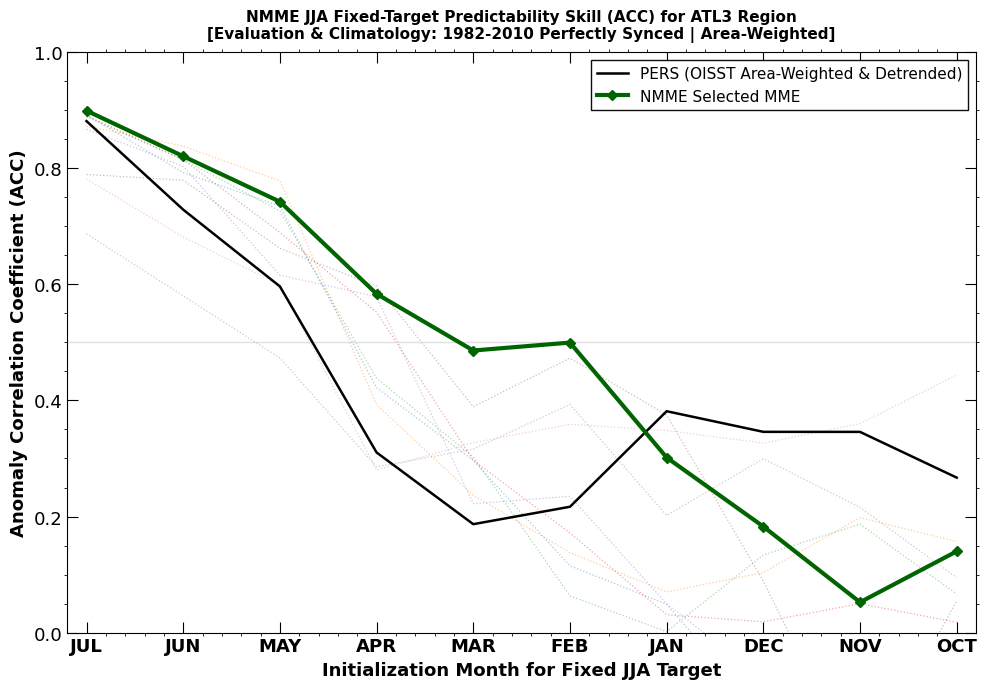

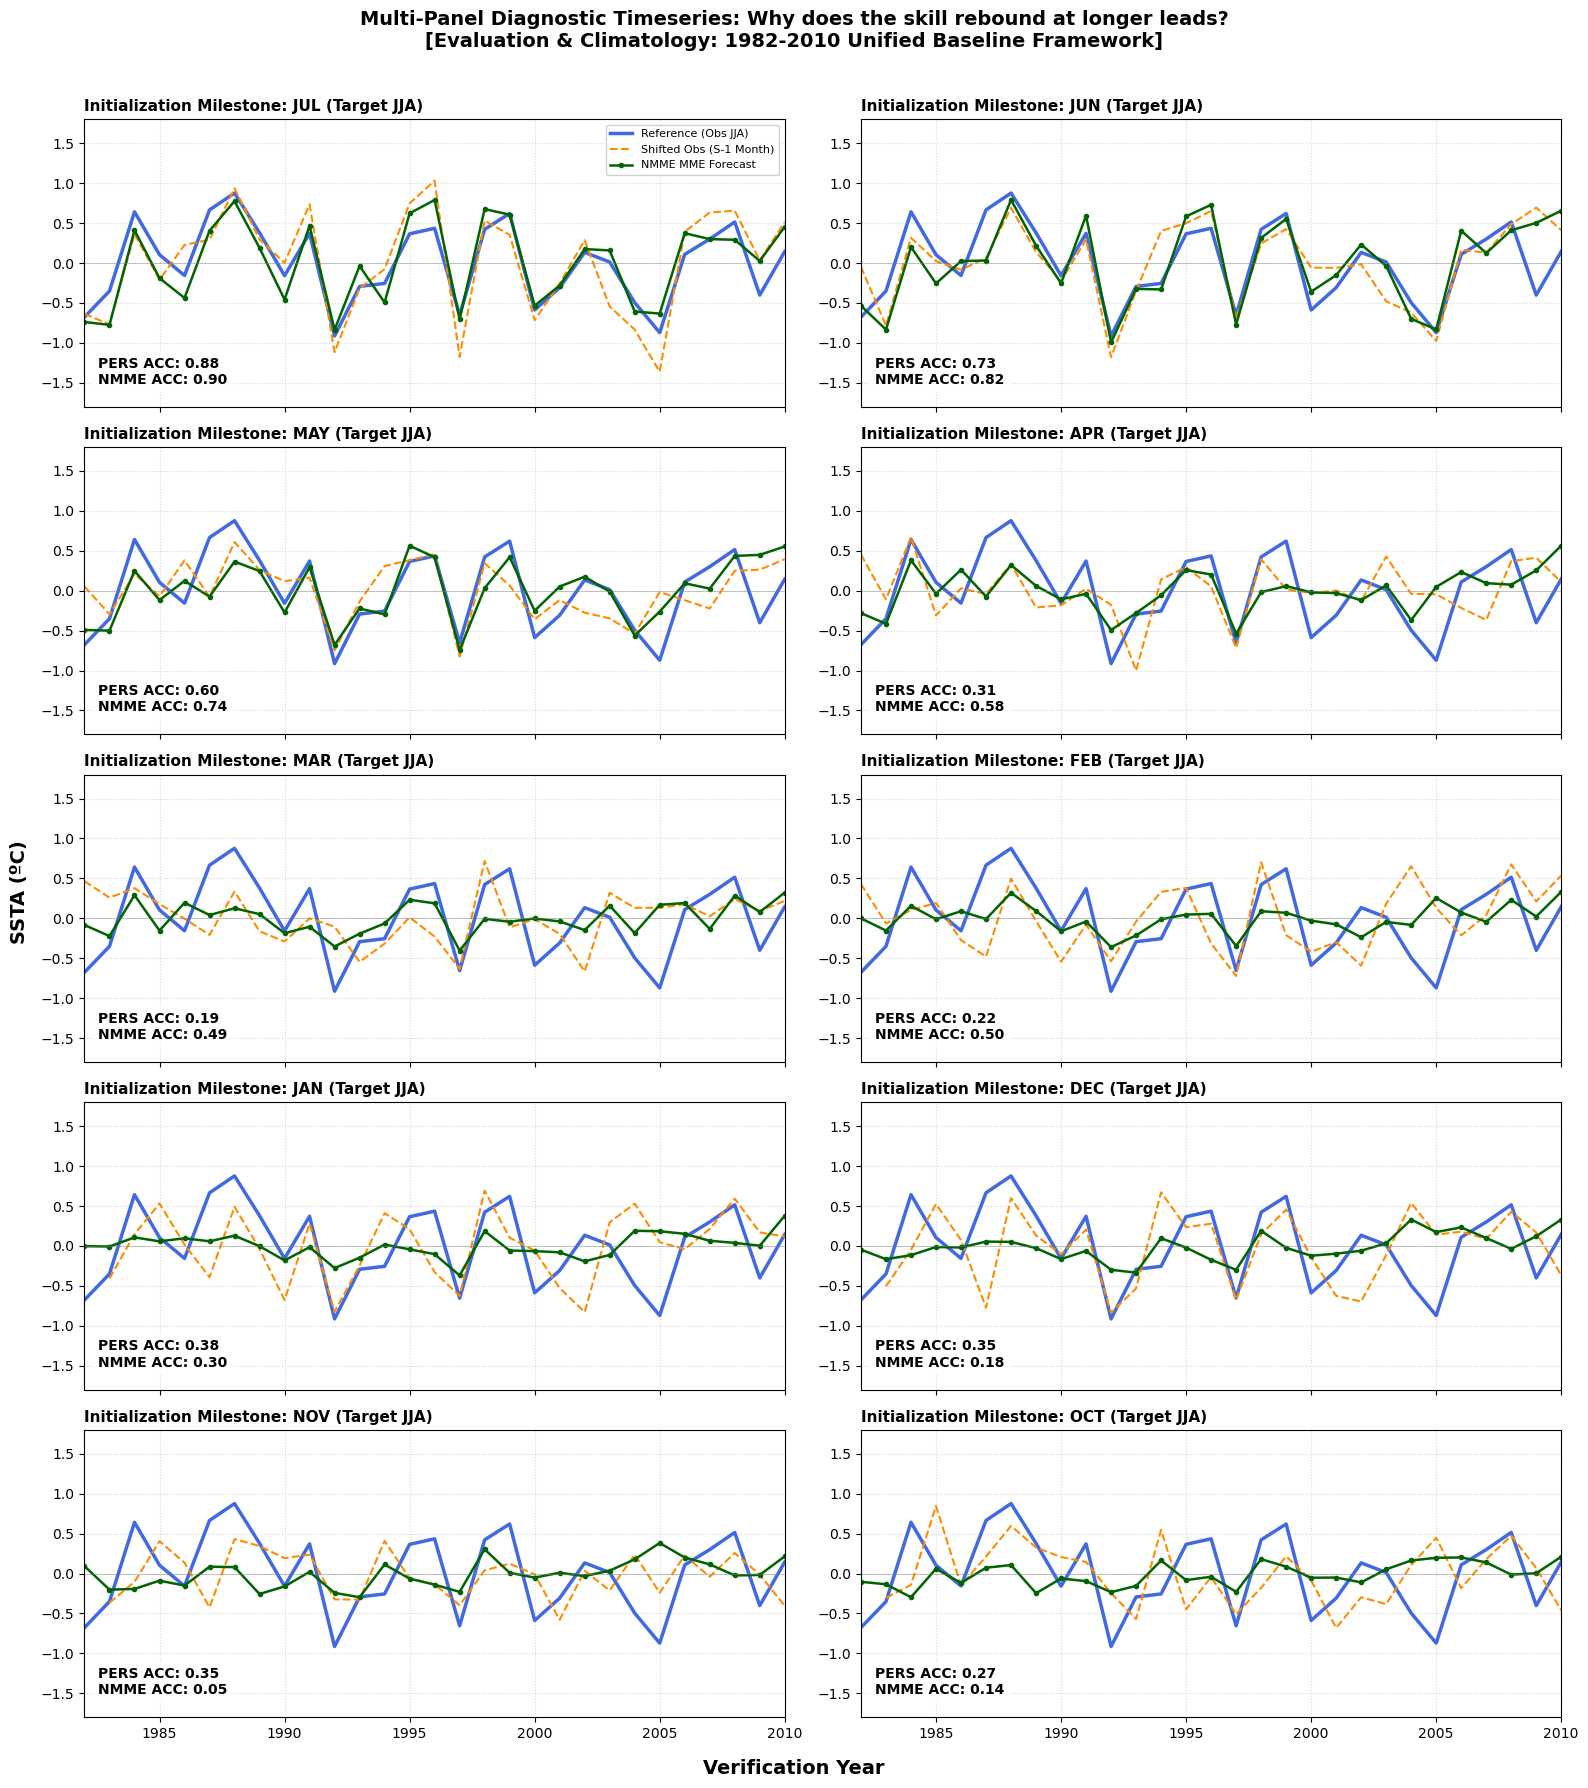

In [32]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import detrend
from scipy.stats import pearsonr
import os

# =========================================================================
# 1. Load and Process Observation Data (Area-Weighted, Climatology First -> Detrend Next)
# =========================================================================
print("Step 1: Loading OISST v2.1 with Cos-Latitude AREA-WEIGHTING (Strict 1982-2010)...")
oisst_dir = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/OBS"
oisst_path = os.path.join(oisst_dir, "OISST_sst.mon.mean.nc")

# Open dataset using standard netcdf4 engine
ds_global = xr.open_dataset(oisst_path, engine='netcdf4')

# Slice ATL3 region precisely using OISST's native coordinates
ds_atl3 = ds_global.sel(lat=slice(-3.0, 3.0), lon=slice(340.0, 360.0))

# [FIX 1] Calculate cos(latitude) in radians for regular grid area-weights
weights = np.cos(np.deg2rad(ds_atl3['lat']))
weights.name = "weights"

# Apply spatial area-weighted mean framework across lat and lon dimensions
with np.errstate(all='ignore'):
    atl3_spatial_mean = ds_atl3['sst'].weighted(weights).mean(dim=['lat', 'lon'], skipna=True)

# Standardize the datetime sequence (Enforce day=1 to align with models)
time_cleaned = pd.to_datetime(ds_global['time'].values)
time_standardized = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_cleaned])

# Construct Pandas DataFrame for 100% downstream code compatibility
df_obs_all = pd.DataFrame({
    'Date': time_standardized,
    'ATL3_raw_SST': atl3_spatial_mean.values
})
df_obs_all['Year'] = df_obs_all['Date'].dt.year
df_obs_all['Month'] = df_obs_all['Date'].dt.month

# [FIX 2] Cut data to 1982-2010 window FIRST
df_obs = df_obs_all[(df_obs_all['Year'] >= 1982) & (df_obs_all['Year'] <= 2010)].reset_index(drop=True)

# -------------------------------------------------------------------------
# [MODIFIED] Compute Anomaly First based on 1982-2010 Climatology Baseline Period
# -------------------------------------------------------------------------
obs_clim_mask = (df_obs['Date'] >= "1982-01-01") & (df_obs['Date'] <= "2010-12-01")
obs_monthly_clim = {
    m: df_obs.loc[obs_clim_mask & (df_obs['Month'] == m), 'ATL3_raw_SST'].mean() 
    for m in range(1, 13)
}
df_obs['ATL3_SSTA_raw'] = df_obs.apply(lambda row: row['ATL3_raw_SST'] - obs_monthly_clim[row['Month']], axis=1)

# [FIX 2] Apply linear detrending (1982-2010) NEXT
df_obs['ATL3_SSTA'] = detrend(df_obs['ATL3_SSTA_raw'].values)
df_obs_indexed = df_obs.set_index('Date')

print("--- Area-Weighted & Detrended 1982-2010 OISST Observation Bounded ---")
print(df_obs[['Date', 'ATL3_raw_SST', 'ATL3_SSTA_raw', 'ATL3_SSTA']].head(12))
print("-------------------------------------------------------------\n")


# =========================================================================
# 2. Define Target Settings (JJA Fixed target, 1982-2010 Eval)
# =========================================================================
nc_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.nc"
ds_all = xr.open_dataset(nc_path)
ds_merged = ds_all.sel(run_type="MERGED")

target_models = [
    'CanCM4i', 'CanSIPSv2', 'CMC1-CanCM3', 'CMC2-CanCM4', 
    'GEM-NEMO', 'NASA-GEOSS2S', 'NCAR-CESM1', 'NCEP-CFSv2'
]
models = [m for m in ds_merged.model.values if m in target_models]
leads = ds_merged.L.values  

eval_years = np.arange(1982, 2011)  # 1982-2010 Evaluation window
start_clim = pd.Timestamp("1982-01-01")
end_clim = pd.Timestamp("2010-12-01")    

init_steps = [
    ('JUL', 7, 0), ('JUN', 6, 0), ('MAY', 5, 0), ('APR', 4, 0), 
    ('MAR', 3, 0), ('FEB', 2, 0), ('JAN', 1, 0), 
    ('DEC', 12, -1), ('NOV', 11, -1), ('OCT', 10, -1)
]
init_labels = [step[0] for step in init_steps]

# [FIX 3] Pre-calculate the 3-month moving mean reference target (JJA) from detrended SSTA
obs_jja_dict = {}
for year in eval_years:
    dates_jja = [pd.Timestamp(f"{year}-06-01"), pd.Timestamp(f"{year}-07-01"), pd.Timestamp(f"{year}-08-01")]
    if all(d in df_obs_indexed.index for d in dates_jja):
        obs_jja_dict[year] = df_obs_indexed.loc[dates_jja, 'ATL3_SSTA'].mean()

target_predict_month = 6 


# =========================================================================
# 3. Compute Persistence Forecast Skill (3-Month Target vs Shifted 1-Month Predictor)
# =========================================================================
print("Step 3: Calculating scientifically aligned Persistence Target-Season skill via OISST...")
persistence_skills = []

for label, month_int, yr_offset in init_steps:
    obs_predictor_list = []
    obs_target_list = []
    
    for year in eval_years:
        if year in obs_jja_dict:
            target_val = obs_jja_dict[year] 
            init_year = year + yr_offset
            init_date = pd.Timestamp(f"{init_year}-{month_int:02d}-01")
            pers_anchor_date = init_date - pd.DateOffset(months=1)
            
            if pers_anchor_date in df_obs_indexed.index:
                predictor_val = df_obs_indexed.loc[pers_anchor_date, 'ATL3_SSTA']
                obs_predictor_list.append(predictor_val)
                obs_target_list.append(target_val)
                
    if len(obs_predictor_list) > 10:
        r_val, _ = pearsonr(obs_predictor_list, obs_target_list)
        persistence_skills.append(r_val)
    else:
        persistence_skills.append(np.nan)


# =========================================================================
# 4. Compute Model Forecast Skills (Climatology First -> Detrend Next Alignment)
# =========================================================================
print("Step 4: Standardizing individual model fields and calculating skills against OISST...")
model_skills = {model: [] for model in models}
mme_field_list = []

for model_name in models:
    ds_mod = ds_merged.sel(model=model_name).sortby('S')
    time_axis_raw = ds_mod['S'].values
    time_axis_S = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_axis_raw])
    ds_mod = ds_mod.assign_coords(S=time_axis_S)
    
    baseline_ds = ds_mod.sel(S=slice(start_clim, end_clim))
    with np.errstate(all='ignore'):
        master_clim_field = baseline_ds['atl3_sst'].mean(dim='M').groupby('S.month').mean(dim='S')
    clim_np_matrix = master_clim_field.values  
    
    gfdl_ssta_raw = ds_mod['atl3_sst'].copy(deep=True)
    for l_idx, lead in enumerate(leads):
        init_months_idx = ds_mod['S'].dt.month.values - 1
        mapped_clim_np = clim_np_matrix[init_months_idx, l_idx]
        for m_idx in range(len(ds_mod.M)):
            gfdl_ssta_raw.loc[dict(L=lead, M=ds_mod.M.values[m_idx])] = \
                ds_mod['atl3_sst'].sel(L=lead, M=ds_mod.M.values[m_idx]).values - mapped_clim_np
                
    gfdl_ssta = gfdl_ssta_raw.copy(deep=True)
    for lead in leads:
        for m_idx in range(len(ds_mod.M)):
            raw_series = gfdl_ssta_raw.sel(L=lead, M=ds_mod.M.values[m_idx]).values
            if not np.isnan(raw_series).any():
                gfdl_ssta.loc[dict(L=lead, M=ds_mod.M.values[m_idx])] = detrend(raw_series)
                
    ens_mean_anom = gfdl_ssta.mean(dim='M') 
    
    model_step_arrays = []
    for label, month_int, yr_offset in init_steps:
        forecast_years_series = []
        
        for year in eval_years:
            init_year = year + yr_offset
            init_date = pd.Timestamp(f"{init_year}-{month_int:02d}-01")
            
            chosen_predict_month = 7 if label == 'JUL' else target_predict_month
            forecast_val = np.nan
            
            if init_date in ens_mean_anom['S'].values:
                mod_at_init = ens_mean_anom.sel(S=init_date)
                for lead_val in mod_at_init['L'].values:
                    v_month = init_date.month + int(lead_val)
                    if v_month > 12: v_month -= 12
                    if v_month == chosen_predict_month:
                        forecast_val = mod_at_init.sel(L=lead_val).values.item()
                        break
            
            forecast_years_series.append(forecast_val)
            
        valid_forecasts = []
        valid_targets = []
        for idx, yr in enumerate(eval_years):
            if not np.isnan(forecast_years_series[idx]) and yr in obs_jja_dict:
                valid_forecasts.append(forecast_years_series[idx])
                valid_targets.append(obs_jja_dict[yr])
                
        if len(valid_forecasts) > 5:
            r_val, _ = pearsonr(valid_forecasts, valid_targets)
            model_skills[model_name].append(r_val)
        else:
            model_skills[model_name].append(np.nan)
            
        model_step_arrays.append(xr.DataArray(forecast_years_series, coords=[eval_years], dims=['year']))
        
    model_mme_da = xr.concat(model_step_arrays, dim=pd.Index(init_labels, name='init_label'))
    mme_field_list.append(model_mme_da)


# =========================================================================
# 5. Compute Multi-Model Ensemble (MME) with Robust Time-Series Alignment
# =========================================================================
print("Step 5: Synching dimensions and calculating Noise-free MME Skill vs OISST...")
master_mme_array = xr.concat(mme_field_list, dim=pd.Index(models, name='model'))
mme_forecast_field = master_mme_array.mean(dim='model', skipna=True)

mme_skills = []
for label in init_labels:
    mme_time_series = []
    obs_time_series = []
    
    for year in eval_years:
        f_val = mme_forecast_field.sel(init_label=label, year=year).values.item()
        if not np.isnan(f_val) and year in obs_jja_dict:
            mme_time_series.append(f_val)
            obs_time_series.append(obs_jja_dict[year])
            
    if len(mme_time_series) > 5:
        r_val, _ = pearsonr(mme_time_series, obs_time_series)
        mme_skills.append(r_val)
    else:
        mme_skills.append(np.nan)


# =========================================================================
# 6. Plotting (MME Standout Verification vs OISST)
# =========================================================================
print("Step 6: Generating high-fidelity fixed target skill plots...")
fig1, ax1 = plt.subplots(figsize=(10, 7))
x_indices = np.arange(len(init_labels))

# Persistence Baseline
ax1.plot(x_indices, persistence_skills, color='black', linewidth=1.8, linestyle='-', label='PERS (OISST Area-Weighted & Detrended)', zorder=8)

# Core individual models
for model_name, skills in model_skills.items():
    if not np.isnan(skills).all():
        ax1.plot(x_indices, skills, linewidth=0.9, alpha=0.4, linestyle=':')

# Multi-Model Ensemble Mean
ax1.plot(x_indices, mme_skills, color='darkgreen', linewidth=3.0, linestyle='-', marker='D', markersize=5, label='NMME Selected MME', zorder=20)

# Layout adjustments
ax1.set_ylim(0.0, 1.0)
ax1.set_xlim(-0.2, len(init_labels) - 0.8)
ax1.set_xticks(x_indices)
ax1.set_xticklabels(init_labels, fontsize=13, fontweight='bold')
ax1.tick_params(axis='both', which='major', direction='in', length=8, labelsize=13)
ax1.yaxis.set_ticks_position('both')
ax1.xaxis.set_ticks_position('both')
ax1.minorticks_on()
ax1.axhline(0.5, color='lightgray', linestyle='-', linewidth=1.0, alpha=0.7)

ax1.set_ylabel("Anomaly Correlation Coefficient (ACC)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Initialization Month for Fixed JJA Target", fontsize=13, fontweight='bold')
ax1.set_title(f"NMME JJA Fixed-Target Predictability Skill (ACC) for ATL3 Region\n[Evaluation & Climatology: 1982-2010 Perfectly Synced | Area-Weighted]", fontsize=11, fontweight='bold', pad=10)
ax1.legend(loc='upper right', edgecolor='black', fancybox=False, fontsize=11, framealpha=0.95)

plt.tight_layout()
# Export Figure 1 to disk
fig1.savefig("fixed_target_skill_plot.jpg", dpi=300, format='jpg')
print("👉 Saved 'fixed_target_skill_plot.jpg'")


# =========================================================================
# 7. Multi-Panel Timeseries Diagnostics by Initialization Month
# =========================================================================
print("Step 7: Generating diagnostic multi-panel timeseries comparison...")
fig2, axes2 = plt.subplots(nrows=5, ncols=2, figsize=(16, 18), sharex=True)
axes_flat2 = axes2.flatten()

jja_ref_series = [obs_jja_dict[yr] if yr in obs_jja_dict else np.nan for yr in eval_years]

for idx, (label, month_int, yr_offset) in enumerate(init_steps):
    ax = axes_flat2[idx]
    
    shifted_obs_series = []
    for year in eval_years:
        init_year = year + yr_offset
        init_date = pd.Timestamp(f"{init_year}-{month_int:02d}-01")
        pers_anchor_date = init_date - pd.DateOffset(months=1)
        
        if pers_anchor_date in df_obs_indexed.index:
            shifted_obs_series.append(df_obs_indexed.loc[pers_anchor_date, 'ATL3_SSTA'])
        else:
            shifted_obs_series.append(np.nan)
            
    nmme_forecast_series = []
    for year in eval_years:
        f_val = mme_forecast_field.sel(init_label=label, year=year).values.item()
        nmme_forecast_series.append(f_val if not np.isnan(f_val) else np.nan)
        
    valid_mask_pers = ~np.isnan(shifted_obs_series) & ~np.isnan(jja_ref_series)
    valid_mask_nmme = ~np.isnan(nmme_forecast_series) & ~np.isnan(jja_ref_series)
    
    acc_pers_val = pearsonr(np.array(shifted_obs_series)[valid_mask_pers], np.array(jja_ref_series)[valid_mask_pers])[0] if sum(valid_mask_pers) > 5 else np.nan
    acc_nmme_val = pearsonr(np.array(nmme_forecast_series)[valid_mask_nmme], np.array(jja_ref_series)[valid_mask_nmme])[0] if sum(valid_mask_nmme) > 5 else np.nan

    ax.plot(eval_years, jja_ref_series, color='royalblue', linewidth=2.5, label='Reference (Obs JJA)')
    ax.plot(eval_years, shifted_obs_series, color='darkorange', linewidth=1.5, linestyle='--', label=f'Shifted Obs (S-1 Month)')
    ax.plot(eval_years, nmme_forecast_series, color='darkgreen', linewidth=1.8, linestyle='-', marker='o', markersize=3, label='NMME MME Forecast')
    
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.6, alpha=0.5)
    ax.set_xlim(1982, 2010)
    ax.set_ylim(-1.8, 1.8)
    ax.grid(True, linestyle=':', alpha=0.5)
    
    text_str = f"PERS ACC: {acc_pers_val:.2f}\nNMME ACC: {acc_nmme_val:.2f}"
    ax.text(0.02, 0.08, text_str, transform=ax.transAxes, fontsize=10, 
            fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    ax.set_title(f"Initialization Milestone: {label} (Target JJA)", fontsize=11, fontweight='bold', loc='left')
    if idx == 0:
        ax.legend(loc='upper right', fontsize=8, framealpha=0.9)

for i in range(len(init_steps), len(axes_flat2)):
    fig2.delaxes(axes_flat2[i])

fig2.text(0.5, 0.01, 'Verification Year', ha='center', fontsize=14, fontweight='bold')
fig2.text(0.01, 0.5, 'SSTA (ºC)', va='center', rotation='vertical', fontsize=14, fontweight='bold')
plt.suptitle("Multi-Panel Diagnostic Timeseries: Why does the skill rebound at longer leads?\n[Evaluation & Climatology: 1982-2010 Unified Baseline Framework]", fontsize=14, fontweight='bold', y=0.99)

plt.tight_layout(rect=[0.02, 0.02, 1, 0.98])

# Export Figure 2 to disk
fig2.savefig("fixed_target_diagnostics_plot.jpg", dpi=300, format='jpg')
print("👉 Saved 'fixed_target_diagnostics_plot.jpg'")

ds_global.close()
print("\nAll pipeline tasks executed successfully and saved to disk.")
plt.show()